<a href="https://colab.research.google.com/github/4zmyyy/AMPG-banten-database/blob/main/Banten-2024-electoral-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

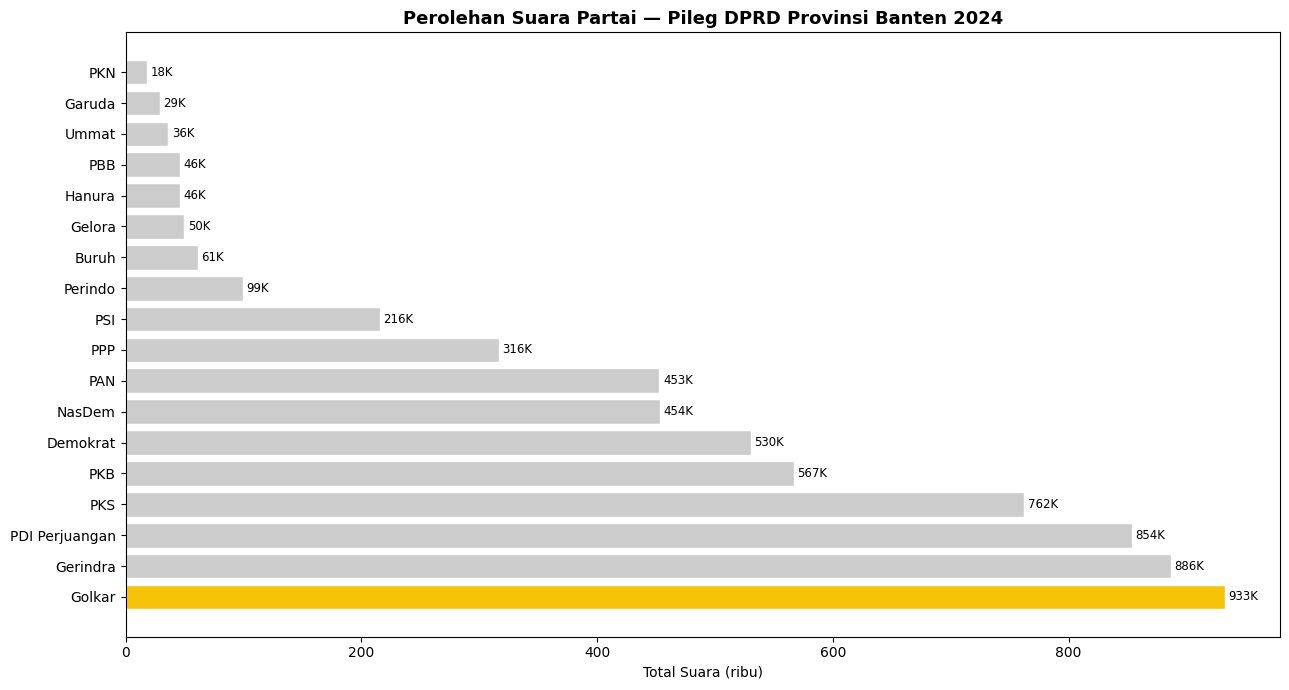

/tmp/ipykernel_2782/399848830.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_2782/399848830.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)


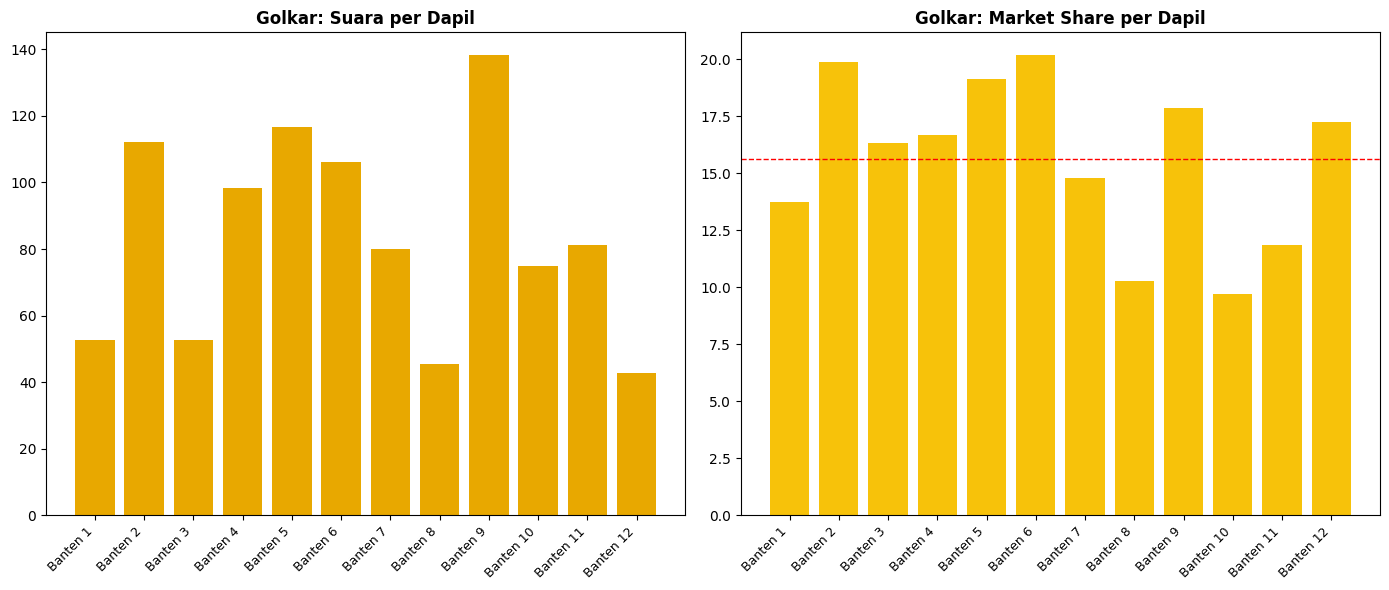

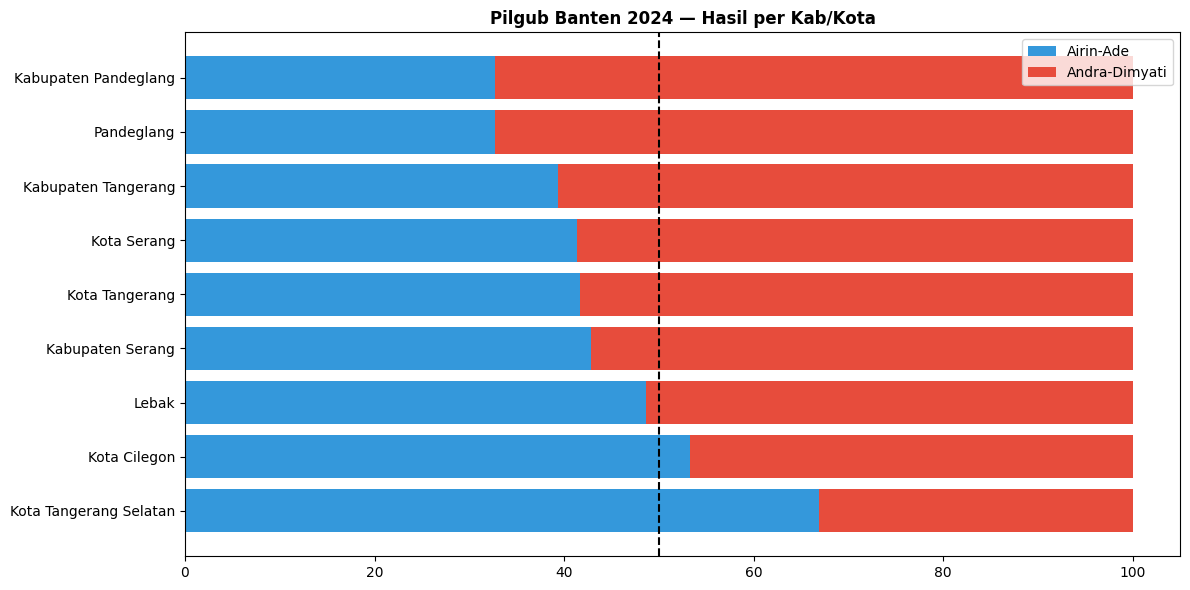

Semua chart selesai!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('pileg_partai_per_dapil.csv')
df_golkar = pd.read_csv('golkar_per_dapil.csv')
df_pilgub = pd.read_csv('pilgub_per_kab_kota.csv')

parties = df[df['partai'] != 'total_suara_sah'].copy()
parties_sorted = parties.sort_values('total', ascending=False)

# Chart 1 - Ranking partai
fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#F7C20A' if p == 'Golkar' else '#CCCCCC' for p in parties_sorted['partai']]
bars = ax.barh(parties_sorted['partai'], parties_sorted['total'] / 1000, color=colors, edgecolor='white')
for bar, val in zip(bars, parties_sorted['total']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f'{val/1000:.0f}K', va='center', fontsize=8.5)
ax.set_xlabel('Total Suara (ribu)')
ax.set_title('Perolehan Suara Partai — Pileg DPRD Provinsi Banten 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_ranking_partai.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 - Golkar per dapil
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes
ax1.bar(df_golkar['dapil'], df_golkar['suara_golkar']/1000, color='#E8A800')
ax1.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
ax1.set_title('Golkar: Suara per Dapil', fontweight='bold')
ax2.bar(df_golkar['dapil'], df_golkar['share_pct'], color='#F7C20A')
ax2.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
ax2.axhline(y=df_golkar['share_pct'].mean(), color='red', linestyle='--', linewidth=1)
ax2.set_title('Golkar: Market Share per Dapil', fontweight='bold')
plt.tight_layout()
plt.savefig('02_golkar_per_dapil.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 - Pilgub
df_pg = df_pilgub.drop_duplicates('kab_kota').sort_values('andra_pct', ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(df_pg))
ax.barh(y, df_pg['airin_pct'], color='#3498db', label='Airin-Ade')
ax.barh(y, df_pg['andra_pct'], left=df_pg['airin_pct'], color='#e74c3c', label='Andra-Dimyati')
ax.axvline(x=50, color='black', linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(df_pg['kab_kota'])
ax.set_title('Pilgub Banten 2024 — Hasil per Kab/Kota', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('03_pilgub.png', dpi=150, bbox_inches='tight')
plt.show()

print("Semua chart selesai!")